# XAUUSD M5 - Data Import & EDA

**Data source:** Dukascopy m5 OHLCV, originally fetched with the use of dukascopy-node app (credits to https://github.com/Leo4815162342) and my ETL pipeline (https://github.com/ady7ady7/cross-market-etl-pipeline) and then stored in DigitalOcean PostgreSQL

**Coverage:** 2021-01-03 - 2026-07-19 (1700+ days, 5+ years of data, 391k+ 5-minute candles in total)

**Note on volume:** Dukascopy volume is tick volume (quote count), not real traded size. Spot XAUUSD has no centralized exchange, so true volume is unavailable. Volume here is a proxy for quoting activity.

The first step is to establish connection with my database, which contains all market data fetched through Dukascopy-node app*. 

(NOT RELEVANT FOR THIS ANALYSIS)
*I've built a pipeline to import and save market data in any DB - please feel free to check the etl-cross-market-pipeline repo on my GitHub if you're interested.

In [3]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

#also added other imports that I needed here
import seaborn as sns
import matplotlib.pyplot as plt

load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT', 5432)}/{os.getenv('DB_NAME')}"
)

After establishing connection it's time to simply fetch market data.
I also do some basic SQL operations at this point to make my life easier later:

- get the time in the et_time (America Eastern Time), since it's the timezone that's the most relevant for Gold (but also for the most liquid financial instruments in most cases)
- extract the day of the week also in the ET
- I do the timestamp ordering, just in case

It's also the time to have a first look at my data.

In [4]:
query = """
SELECT
    timestamp AT TIME ZONE 'America/New_York' AS et_time,
    open, 
    high, 
    low, 
    close, 
    volume,
    EXTRACT(DOW FROM timestamp AT TIME ZONE 'America/New_York') AS day_of_week,
    (timestamp AT TIME ZONE 'America/New_York')::date AS trade_date
FROM xauusd_m5_tradfi_ohlcv
ORDER BY timestamp
"""

df = pd.read_sql(query, engine)
df.head()

,et_time,open,high,low,close,volume,day_of_week,trade_date
0,2021-01-03 17:00:00,1904.998,1910.898,1903.288,1908.850,0.68,0.0,2021-01-03
1,2021-01-03 17:05:00,1908.878,1909.258,1907.618,1908.568,0.46,0.0,2021-01-03
2,2021-01-03 17:10:00,1908.518,1909.405,1907.665,1908.805,0.21,0.0,2021-01-03
3,2021-01-03 17:15:00,1908.785,1909.678,1907.978,1909.358,0.09,0.0,2021-01-03
4,2021-01-03 17:20:00,1909.368,1910.588,1909.005,1909.048,0.14,0.0,2021-01-03


In [5]:
print(f"Shape: {df.shape}")
df['day_of_week'] = df['day_of_week'].astype(int)
df['trade_date'] = pd.to_datetime(df['trade_date'])


print(df.dtypes)

print(f"\nDate range: {df['et_time'].min()} - {df['et_time'].max()}")
print(f"Unique trade dates: {df['trade_date'].nunique()}")

print(f"Null counts: {df.isnull().sum()}")


Shape: (391955, 8)
et_time        datetime64[us]
open                  float64
high                  float64
low                   float64
close                 float64
volume                float64
day_of_week             int64
trade_date      datetime64[s]
dtype: object

Date range: 2021-01-03 17:00:00 - 2026-07-19 17:55:00
Unique trade dates: 1723
Null counts: et_time        0
open           0
high           0
low            0
close          0
volume         0
day_of_week    0
trade_date     0
dtype: int64


Now this is somewhat expected, as market data was initially gathered through Dukascopy, which is one of the most prominent financial brokers - it's licensed and well known on the market.

However, we also have to keep in mind that volume data they offer is not real market data, but only their platform(s) data, and it's very important. Basically it means that volume analysis is not the right choice in this case, as it's not tied to the real market volume.

There aren't any nulls, but perhaps we're missing some days or candles - maybe they're simply not there - they wouldn't appear as NULL.

In [6]:
expected_bars = pd.date_range(
    start=df['et_time'].min(),
    end=df['et_time'].max(),
    freq='5min'
)
missing_bars = expected_bars.difference(df['et_time'])
print(f"Expected 5-min bars: {len(expected_bars)}")
print(f"Actual bars: {len(df)}")
print(f"Missing bars: {len(missing_bars)}")

Expected 5-min bars: 582636
Actual bars: 391955
Missing bars: 190681


As we can see, about 32.7% of our candles are missing.

However, we must also be aware of the fact that financial markets run only from late Sunday until Friday, and that there are also holidays, when the markets are closed. With that in mind we can move on to do some more robust check, and look which days have the most missing bars.


In [7]:
missing_df = pd.DataFrame({'et_time': missing_bars})
missing_df['day_of_week'] = missing_df['et_time'].dt.dayofweek  # 0=Mon, 6=Sun

print("Missing bars by day of week:")
print(missing_df['day_of_week'].value_counts().sort_index())

weekday_missing = missing_df[missing_df['day_of_week'] < 5].copy()
weekday_missing['hour'] = weekday_missing['et_time'].dt.hour

print("Missing weekday bars by hour:")
print(weekday_missing['hour'].value_counts().sort_index())

Missing bars by day of week:
day_of_week
0     5448
1     3911
2     4173
3     5022
4    31564
5    83232
6    57331
Name: count, dtype: int64
Missing weekday bars by hour:
hour
0       228
1       228
2       229
3       228
4       228
5       228
6       228
7       228
8       228
9       229
10      228
11      303
12      486
13      696
14      780
15    10572
16     9302
17     3651
18     3638
19     3636
20     3636
21     3636
22     3636
23     3636
Name: count, dtype: int64


To run a proper check, I will actually install a new library - pandas_market_calendars, which contains the whole trading calendar for every symbol




In [8]:
import pandas_market_calendars as mcal
cal = mcal.get_calendar('CMEGlobex_Gold')

start_date = df['et_time'].min()
end_date = df['et_time'].max()
calendar = cal.schedule(start_date = start_date, end_date = end_date)
print(calendar)



                         market_open              market_close
2021-01-04 2021-01-03 23:00:00+00:00 2021-01-04 22:00:00+00:00
2021-01-05 2021-01-04 23:00:00+00:00 2021-01-05 22:00:00+00:00
2021-01-06 2021-01-05 23:00:00+00:00 2021-01-06 22:00:00+00:00
2021-01-07 2021-01-06 23:00:00+00:00 2021-01-07 22:00:00+00:00
2021-01-08 2021-01-07 23:00:00+00:00 2021-01-08 22:00:00+00:00
...                              ...                       ...
2026-07-13 2026-07-12 22:00:00+00:00 2026-07-13 21:00:00+00:00
2026-07-14 2026-07-13 22:00:00+00:00 2026-07-14 21:00:00+00:00
2026-07-15 2026-07-14 22:00:00+00:00 2026-07-15 21:00:00+00:00
2026-07-16 2026-07-15 22:00:00+00:00 2026-07-16 21:00:00+00:00
2026-07-17 2026-07-16 22:00:00+00:00 2026-07-17 21:00:00+00:00

[1430 rows x 2 columns]


Now we have a proper list of trading days without all the holidays and weekends, and we can properly calculate the expected bars and then check if there are any missing ones in a proper way.

Gold trades Sun 18:00 ET through Fri 17:00 ET. This means Sunday bars appear in the dataset as a separate `trade_date`, but they logically belong to the Monday session. We drop Sunday bars to align with the CME calendar (Mon–Fri trading days only).


In [9]:
type(calendar)
#it's a pandas DF

df = df[df['et_time'].dt.dayofweek != 6].copy()
print(f"Rows after dropping Sundays: {len(df)}")
print(f"Unique trade_dates: {df['trade_date'].nunique()}")



Rows after dropping Sundays: 366042
Unique trade_dates: 1437


So now we are sitting at 1430 days in our calendar vs 1437 days in the dataframe - it's close enough and if the dates aligh we shouldn't really bother with that much more.

In [10]:
calendar_et = calendar.copy()
calendar_et['market_open'] = calendar['market_open'].dt.tz_convert('America/New_York').dt.tz_localize(None)
calendar_et['market_close'] = calendar['market_close'].dt.tz_convert('America/New_York').dt.tz_localize(None)

df_dates = set(df['trade_date'].dt.date)
cal_dates = set(calendar_et.index.date)

only_in_df = df_dates - cal_dates
only_in_cal = cal_dates - df_dates

print(f"Days in df but not in calendar: {len(only_in_df)}")
print(sorted(only_in_df))
print(f"\nDays in calendar but not in df: {len(only_in_cal)}")
print(sorted(only_in_cal))


Days in df but not in calendar: 8
[datetime.date(2022, 12, 26), datetime.date(2023, 1, 2), datetime.date(2023, 12, 25), datetime.date(2024, 1, 1), datetime.date(2024, 12, 25), datetime.date(2025, 1, 1), datetime.date(2025, 12, 25), datetime.date(2026, 1, 1)]

Days in calendar but not in df: 1
[datetime.date(2021, 10, 15)]


Data coverage is 99.9% complete, and it's the best time to move forward!

Now it's time to add some additional data which will allow us to categorize data more easily.

In [11]:


df['candle_range'] = df['high'] - df['low']
df['et_hour'] = df['et_time'].dt.hour
df['et_minute'] = df['et_time'].dt.minute
 
df.head(5)




,et_time,open,high,low,close,volume,day_of_week,trade_date,candle_range,et_hour,et_minute
84,2021-01-04 00:00:00,1921.648,1922.658,1921.448,1922.305,0.20,1,2021-01-04,1.210,0,0
85,2021-01-04 00:05:00,1922.315,1923.605,1921.345,1923.468,0.14,1,2021-01-04,2.260,0,5
86,2021-01-04 00:10:00,1923.485,1923.818,1922.585,1922.745,0.21,1,2021-01-04,1.233,0,10
87,2021-01-04 00:15:00,1922.755,1923.835,1922.635,1923.835,0.16,1,2021-01-04,1.200,0,15
88,2021-01-04 00:20:00,1923.865,1925.475,1923.668,1925.335,0.45,1,2021-01-04,1.807,0,20


Now it's time to do a mock price overview on some chosen period to test if everything looks fine.

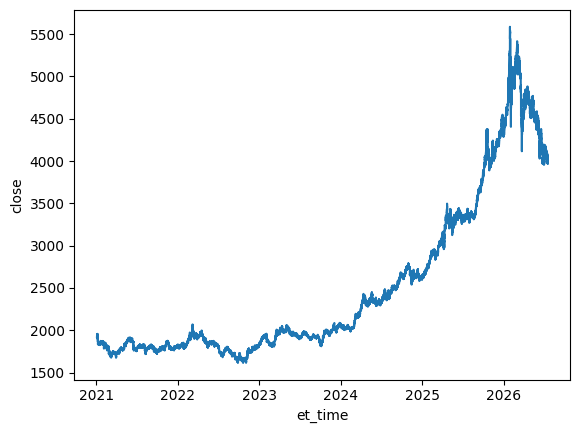

In [12]:
close_prices_df = df[['et_time', 'close']].copy()


line_chart = sns.lineplot(
    close_prices_df,
    x = 'et_time',
    y = 'close'
)

plt.show()

Everything looks fine, there are no visible gaps and the price represents the actual GOLD prices, as I've double checked it with the online charts.

I've also done a few more individual checks for 10 random candles, and all the prices matched.
This manual step is very important to identify the issues early, but we can move on.

We've just added the candle range for each 5-minute candle, and I'd like to explore how these ranges differ - the boxplot will be the perfect tool to use for that.

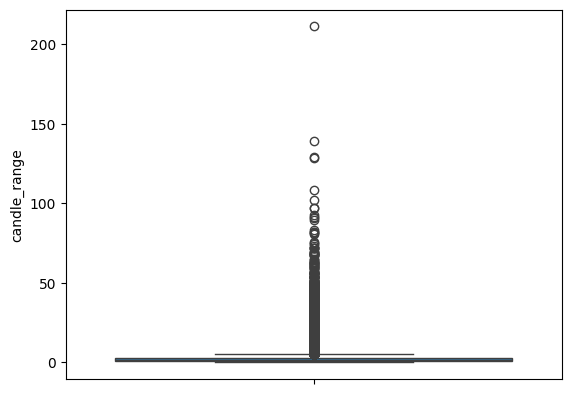

In [13]:
candles_range_df = df[['et_time', 'candle_range']].copy()

boxplot = sns.boxplot(
    candles_range_df['candle_range']
)

plt.show()

Now, as you can clearly see, the current approach doesn't allow me to see much, as there is a lot of outliers, which are probably the candles appearing mostly during high-impact market news or unexpected world events.

The IQR and median are very close to 0 on this chart, and yet I'm unable to make any meaningful observations with the current scale.

I definitely have to reconsider this approach to actually be able to see the real candle ranges in a visible and reasonable way, so that we don't lose too much data.

The first approach that naturally comes to my mind is aggregating the candles in bigger buckets - perhaps 30 minute buckets will be clearer to make observations.

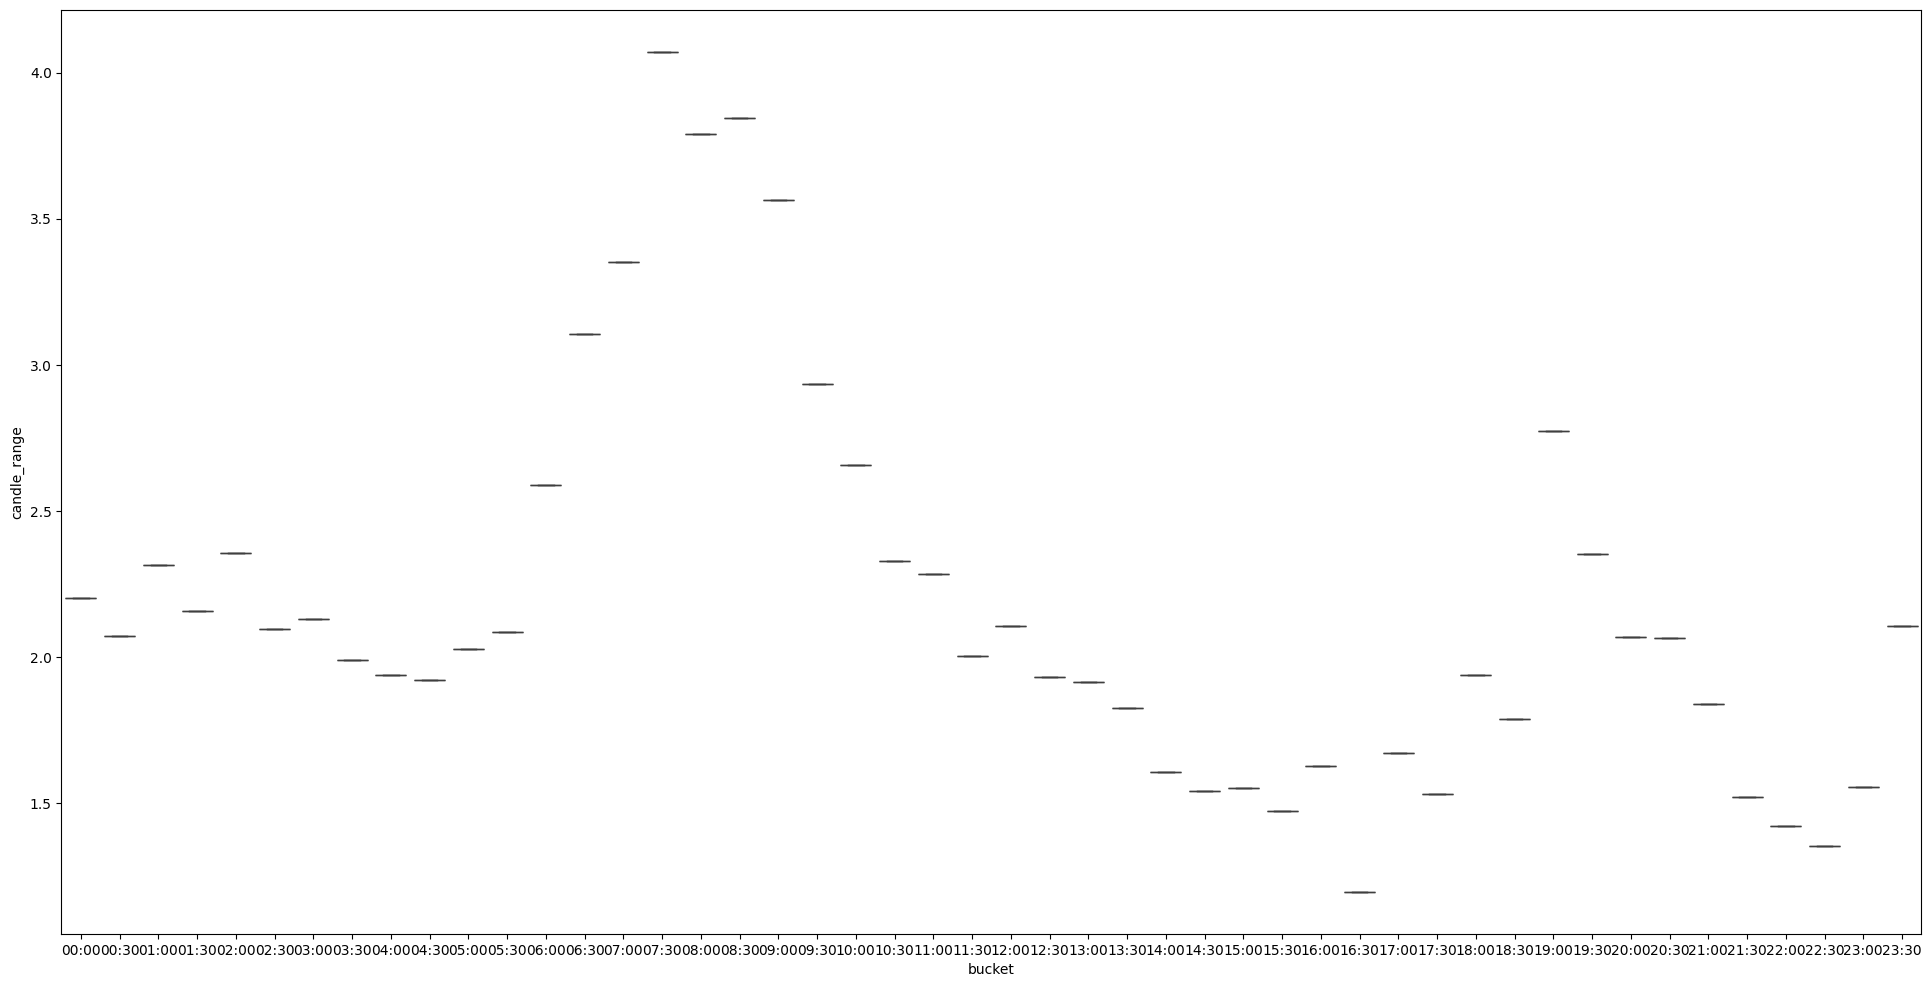

In [14]:
df.head(5)
df['bucket'] = df['et_time'].dt.floor('30min').dt.strftime('%H:%M')


plt.figure(figsize = (24, 12))
df_bucket_df = df.groupby('bucket')['candle_range'].mean().reset_index()
boxplot = sns.boxplot(
    df_bucket_df,
    x = 'bucket',
    y = 'candle_range'
)
plt.show()


With this huge figure size we're able to clearly see that there seem to be meaningful differences in terms of average candle ranges in different time buckets.

This image is still a bit unclear, as there's truly a lot of buckets, so perhaps it would make sense to show these ordered in a table.

Also it might make sense to verify statistically if the differences are truly meaningful or just random noise.

In [15]:

df_bucket_df= df_bucket_df.sort_values(by = 'candle_range', ascending = False)
df_bucket_df.head(15)

,bucket,candle_range
15,07:30,4.071128
17,08:30,3.844618
16,08:00,3.791308
18,09:00,3.563067
14,07:00,3.351293
13,06:30,3.104027
19,09:30,2.932764
38,19:00,2.773176
20,10:00,2.657464
12,06:00,2.590258


This table gives a clear indication that the highest candles of the day are during the 6:30 - 10:30 (as 10:00 bucket ends at 10:30) ET time, which could help us further investigate this particular daily bucket more thoroughly.

All of the candles from that period are to be found in the top 10 most volatile daily buckets.


I'm also interested whether highs or lows of a days tend to form within the most volatile candle ranges, somewhere around that 6:30-10:30 ET time period.

In [16]:
hod = df.loc[df.groupby('trade_date')['high'].idxmax(), ['trade_date', 'bucket']]
lod = df.loc[df.groupby('trade_date')['low'].idxmin(), ['trade_date', 'bucket']]

print(hod['bucket'].value_counts().head(10))
print(lod['bucket'].value_counts().head(10))

bucket
00:00    113
23:30     93
07:30     86
08:30     67
01:00     59
06:30     59
07:00     55
09:00     55
08:00     54
00:30     51
Name: count, dtype: int64
bucket
00:00    143
07:30     94
08:00     78
08:30     66
06:30     64
23:30     58
01:00     56
09:00     52
01:30     42
00:30     41
Name: count, dtype: int64


While 23:30 - 00:00 seem to be one interesting observation, we can clearly see the candles from the 6:30 onwards again in the most popular high of the day/low of the day candles.